In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# ── Grafik stili ayarları ──────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

# ── Numpy yazdırma hassasiyeti ─────────────────────────────────────────────
np.set_printoptions(precision=4, suppress=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')

✅ Tüm kütüphaneler başarıyla yüklendi.
   NumPy  : 2.0.2
   Pandas : 2.2.2


In [5]:
from google.colab import files
files.upload()

Saving insurance.csv to insurance (1).csv


{'insurance (1).csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,sou

In [6]:
import pandas as pd

# ── Veri setini oku ───────────────────────────────────────────────────────
df_insurance = pd.read_csv('insurance.csv')

# ── Temel bilgiler ────────────────────────────────────────────────────────
print('=' * 60)
print('📊 SİGORTA VERİSİ (Insurance Dataset)')
print('=' * 60)
print(f'  Satır sayısı       : {df_insurance.shape[0]:,}')
print(f'  Sütun sayısı       : {df_insurance.shape[1]}')
print(f'  Yaş aralığı        : {df_insurance["age"].min()} → {df_insurance["age"].max()}')
print(f'  Sigara içen sayısı : {df_insurance[df_insurance["smoker"] == "yes"].shape[0]}')
print(f'  Ortalama Ücret     : {df_insurance["charges"].mean():.2f} $')
print()

# ── İlk 5 satır ───────────────────────────────────────────────────────────
print('İlk 5 satır:')
df_insurance[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']].head()

📊 SİGORTA VERİSİ (Insurance Dataset)
  Satır sayısı       : 1,338
  Sütun sayısı       : 7
  Yaş aralığı        : 18 → 64
  Sigara içen sayısı : 274
  Ortalama Ücret     : 13270.42 $

İlk 5 satır:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# ── Eksik değer analizi ───────────────────────────────────────────────────
null_counts = df_insurance.isnull().sum()
null_pct    = (null_counts / len(df_insurance) * 100).round(2)

null_df = pd.DataFrame({
    'Eksik Sayı': null_counts,
    'Eksik Yüzde (%)': null_pct,
    'Veri Tipi': df_insurance.dtypes
}).sort_values('Eksik Sayı', ascending=False)

# Sadece eksik değer içeren sütunları göster (Eğer hiç yoksa boş dönecektir)
print('📋 Eksik Değer Raporu:')
print(null_df.to_string())  # Tüm sütunların durumunu görmek için direkt yazdırabilirsiniz
print()
print(f'⚠️  Toplam {(null_counts > 0).sum()} sütunda eksik veri mevcut.')

📋 Eksik Değer Raporu:
          Eksik Sayı  Eksik Yüzde (%) Veri Tipi
age                0              0.0     int64
sex                0              0.0    object
bmi                0              0.0   float64
children           0              0.0     int64
smoker             0              0.0    object
region             0              0.0    object
charges            0              0.0   float64

⚠️  Toplam 0 sütunda eksik veri mevcut.


In [8]:
# ── İstatistiksel özet ────────────────────────────────────────────────────
stats = df_insurance[['age', 'bmi', 'charges']].describe().round(3)

# İçgörüler yazdır
print('📈 İstatistiksel Özet:')
print(stats)
print()
print('💡 İçgörüler:')
print(f'  • Ortalama Yaş       : {stats.loc["mean", "age"]:.1f} yıl')
print(f'  • Ortalama BMI (VKİ) : {stats.loc["mean", "bmi"]:.1f}')
print(f'  • Ortalama Ücret     : {stats.loc["mean", "charges"]:.2f} $')
print(f'  • Ücret aralığı      : {stats.loc["min","charges"]:.2f} $ → {stats.loc["max","charges"]:.2f} $')
print(f'  • Ücret Standart S.  : {stats.loc["std","charges"]:.2f} $ (ücretlerde yüksek çeşitlilik/sapma var)')

📈 İstatistiksel Özet:
            age       bmi    charges
count  1338.000  1338.000   1338.000
mean     39.207    30.663  13270.422
std      14.050     6.098  12110.011
min      18.000    15.960   1121.874
25%      27.000    26.296   4740.287
50%      39.000    30.400   9382.033
75%      51.000    34.694  16639.913
max      64.000    53.130  63770.428

💡 İçgörüler:
  • Ortalama Yaş       : 39.2 yıl
  • Ortalama BMI (VKİ) : 30.7
  • Ortalama Ücret     : 13270.42 $
  • Ücret aralığı      : 1121.87 $ → 63770.43 $
  • Ücret Standart S.  : 12110.01 $ (ücretlerde yüksek çeşitlilik/sapma var)


In [9]:
# ── Sütun seçimi ve tip dönüşümü ─────────────────────────────────────────
# Sigorta veri setindeki sayısal analiz yapılacak sütunlar
cols = ['age', 'bmi', 'charges']
data = df_insurance[cols].copy()

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

n_before = len(data)
data = data.dropna()
n_after  = len(data)

print(f'🧹 Temizleme Raporu:')
print(f'  Önceki satır sayısı : {n_before:,}')
print(f'  Sonraki satır sayısı: {n_after:,}')
print(f'  Silinen satır sayısı: {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.2f}%)')
print()

# ── IQR ile aykırı değer analizi ──────────────────────────────────────────
print('🔍 IQR Aykırı Değer Analizi:')
for col in cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f'  {col:10s} | IQR={IQR:.2f} | [{lower:.2f}, {upper:.2f}] | {len(outliers):,} aykırı değer ({len(outliers)/len(data)*100:.2f}%)')

print()
print('✅ Veri temizleme tamamlandı.')
data.head()

🧹 Temizleme Raporu:
  Önceki satır sayısı : 1,338
  Sonraki satır sayısı: 1,338
  Silinen satır sayısı: 0 (0.00%)

🔍 IQR Aykırı Değer Analizi:
  age        | IQR=24.00 | [-9.00, 87.00] | 0 aykırı değer (0.00%)
  bmi        | IQR=8.40 | [13.70, 47.29] | 9 aykırı değer (0.67%)
  charges    | IQR=11899.63 | [-13109.15, 34489.35] | 139 aykırı değer (10.39%)

✅ Veri temizleme tamamlandı.


,age,bmi,charges
0,19,27.900,16884.92400
1,18,33.770,1725.55230
2,28,33.000,4449.46200
3,33,22.705,21984.47061
4,32,28.880,3866.85520


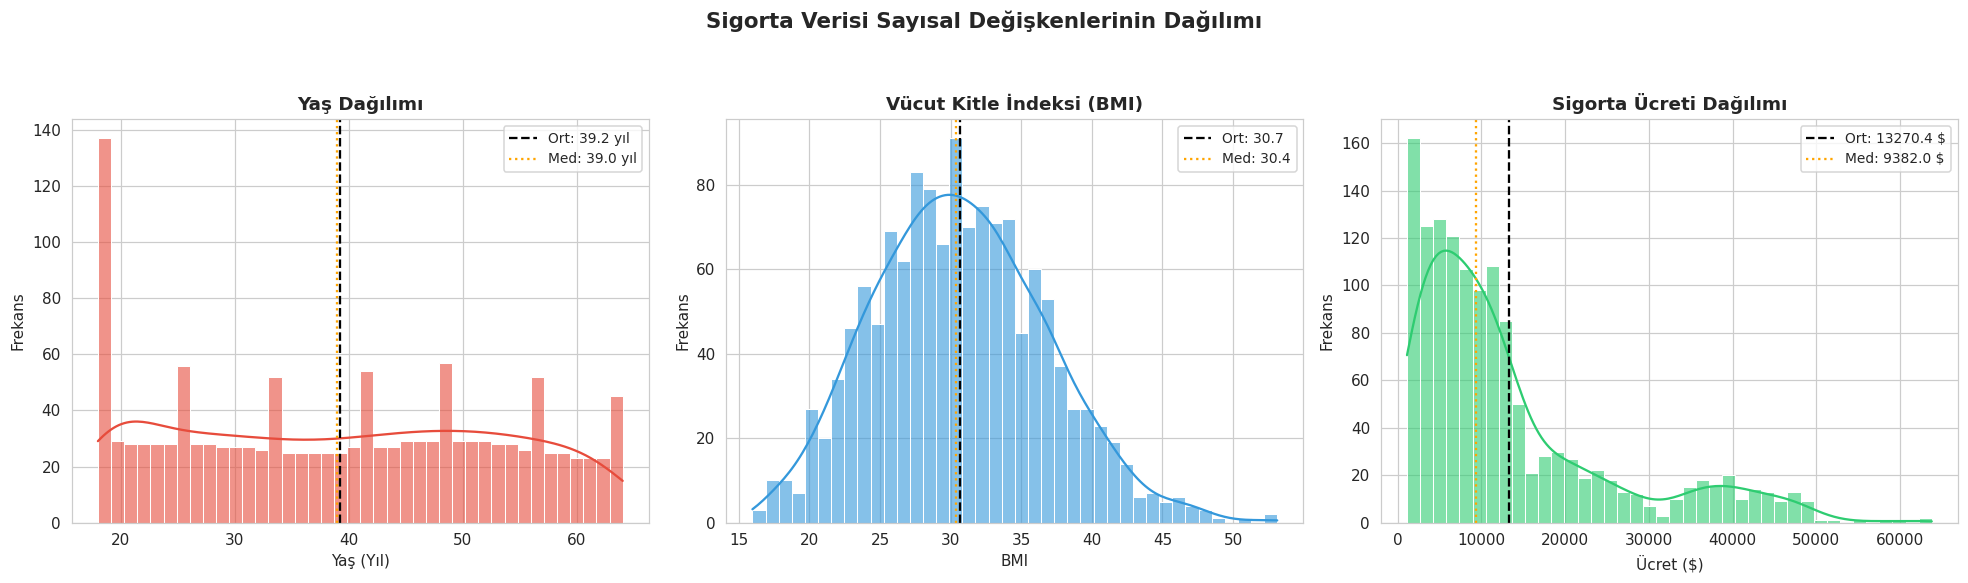

💡 Yorum:
  • Yaş Dağılımı: Genç yaş grubunda (18-19 yaş) bir yoğunluk olmakla birlikte genel olarak dengeli bir dağılım göstermektedir. Ortalama ve medyan birbirine çok yakındır.
  • BMI (Vücut Kitle İndeksi): Tam anlamıyla simetrik ve normal bir dağılıma (çan eğrisi) sahiptir. Ortalama ve medyan değerleri neredeyse aynıdır.
  • Sigorta Ücreti (Charges): Dağılım sağdan çarpıktır (pozitif çarpık). Çoğu kişi daha düşük (10.000$ ve altı) sigorta ücreti öderken, az sayıda kişi yüksek ücretler ödemektedir. Bu nedenle medyan değeri, ortalamadan belirgin şekilde daha düşüktür.


In [10]:

# ── Dağılım grafikleri ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sigorta Verisi Sayısal Değişkenlerinin Dağılımı', fontsize=14, fontweight='bold', y=1.05)

# Grafik bilgileri: (Sütun adı, Renk, Başlık, X ekseni etiketi, Birim)
vars_info = [
    ('age', '#e74c3c', 'Yaş Dağılımı', 'Yaş (Yıl)', 'yıl'),
    ('bmi', '#3498db', 'Vücut Kitle İndeksi (BMI)', 'BMI', ''),
    ('charges', '#2ecc71', 'Sigorta Ücreti Dağılımı', 'Ücret ($)', '$')
]

for ax, (col, color, title, xlabel, unit) in zip(axes, vars_info):
    # Histogram + KDE (Yoğunluk Eğrisi)
    sns.histplot(data[col], bins=40, kde=True, color=color, alpha=0.6, ax=ax)

    # Ortalama ve medyan çizgileri
    mean_val   = data[col].mean()
    median_val = data[col].median()
    unit_str   = f' {unit}' if unit else ''

    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'Ort: {mean_val:.1f}{unit_str}')
    ax.axvline(median_val, color='orange', linestyle=':',  linewidth=1.5, label=f'Med: {median_val:.1f}{unit_str}')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekans')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Yaş Dağılımı: Genç yaş grubunda (18-19 yaş) bir yoğunluk olmakla birlikte genel olarak dengeli bir dağılım göstermektedir. Ortalama ve medyan birbirine çok yakındır.')
print('  • BMI (Vücut Kitle İndeksi): Tam anlamıyla simetrik ve normal bir dağılıma (çan eğrisi) sahiptir. Ortalama ve medyan değerleri neredeyse aynıdır.')
print('  • Sigorta Ücreti (Charges): Dağılım sağdan çarpıktır (pozitif çarpık). Çoğu kişi daha düşük (10.000$ ve altı) sigorta ücreti öderken, az sayıda kişi yüksek ücretler ödemektedir. Bu nedenle medyan değeri, ortalamadan belirgin şekilde daha düşüktür.')

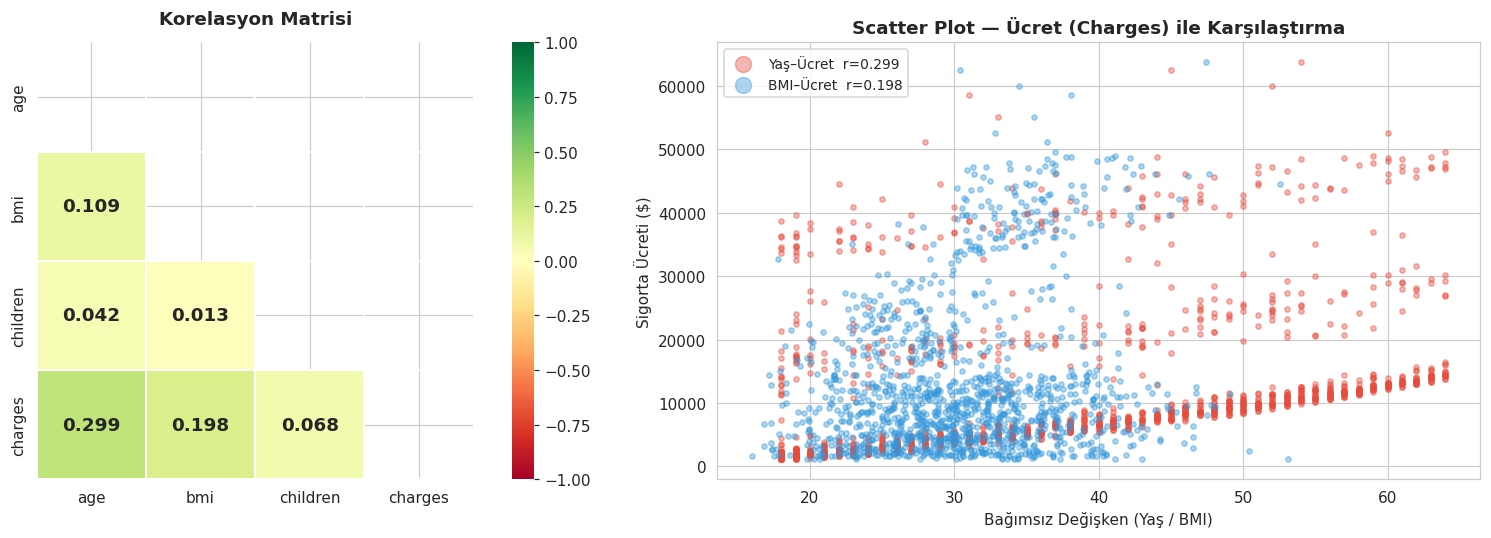

💡 Yorum:
  • Yaş–Ücret korelasyonu: r = 0.299  (Zayıf-orta düzeyde pozitif bir ilişki var. Yaş arttıkça ücretler genel olarak artıyor.)
  • BMI–Ücret korelasyonu: r = 0.198  (Zayıf pozitif ilişki var.)
  • Doğrusal ilişkiler hava durumundaki sıcaklıklar kadar net/kusursuz değildir çünkü sigorta ücretlerini doğrudan etkileyen "smoker" (sigara kullanımı) gibi çok güçlü kategorik değişkenler de devrededir.
  • Bu veri setinde regresyon modelleri kurulurken kategorik değişkenlerin de modele dahil edilmesi doğrusal tahmini çok daha güçlü kılacaktır.


In [20]:

# Eğer önceki adımlardan 'data' değişkeniniz tanımlı değilse, ana veriyi kopyalayalım:
data = df_insurance.copy()

# ── Korelasyon ısı haritası ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sol: Korelasyon matrisi (Sayısal değişkenler için)
corr_matrix = data[['age', 'bmi', 'children', 'charges']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=1, ax=axes[0],
    annot_kws={'size': 12, 'weight': 'bold'}
)
axes[0].set_title('Korelasyon Matrisi', fontweight='bold', pad=12)

# Sağ: Scatter plot (Yaş ve BMI sütunlarının Ücret ile değişimi)
axes[1].scatter(data['age'], data['charges'], alpha=0.4, s=12,
                color='#e74c3c', label=f'Yaş–Ücret  r={corr_matrix.loc["age","charges"]:.3f}')
axes[1].scatter(data['bmi'], data['charges'], alpha=0.4, s=12,
                color='#3498db', label=f'BMI–Ücret  r={corr_matrix.loc["bmi","charges"]:.3f}')
axes[1].set_xlabel('Bağımsız Değişken (Yaş / BMI)')
axes[1].set_ylabel('Sigorta Ücreti ($)')
axes[1].set_title('Scatter Plot — Ücret (Charges) ile Karşılaştırma', fontweight='bold')
axes[1].legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.show()

print('💡 Yorum:')
r_age = corr_matrix.loc['age','charges']
r_bmi = corr_matrix.loc['bmi','charges']
print(f'  • Yaş–Ücret korelasyonu: r = {r_age:.3f}  (Zayıf-orta düzeyde pozitif bir ilişki var. Yaş arttıkça ücretler genel olarak artıyor.)')
print(f'  • BMI–Ücret korelasyonu: r = {r_bmi:.3f}  (Zayıf pozitif ilişki var.)')
print(f'  • Doğrusal ilişkiler hava durumundaki sıcaklıklar kadar net/kusursuz değildir çünkü sigorta ücretlerini doğrudan etkileyen "smoker" (sigara kullanımı) gibi çok güçlü kategorik değişkenler de devrededir.')
print(f'  • Bu veri setinde regresyon modelleri kurulurken kategorik değişkenlerin de modele dahil edilmesi doğrusal tahmini çok daha güçlü kılacaktır.')

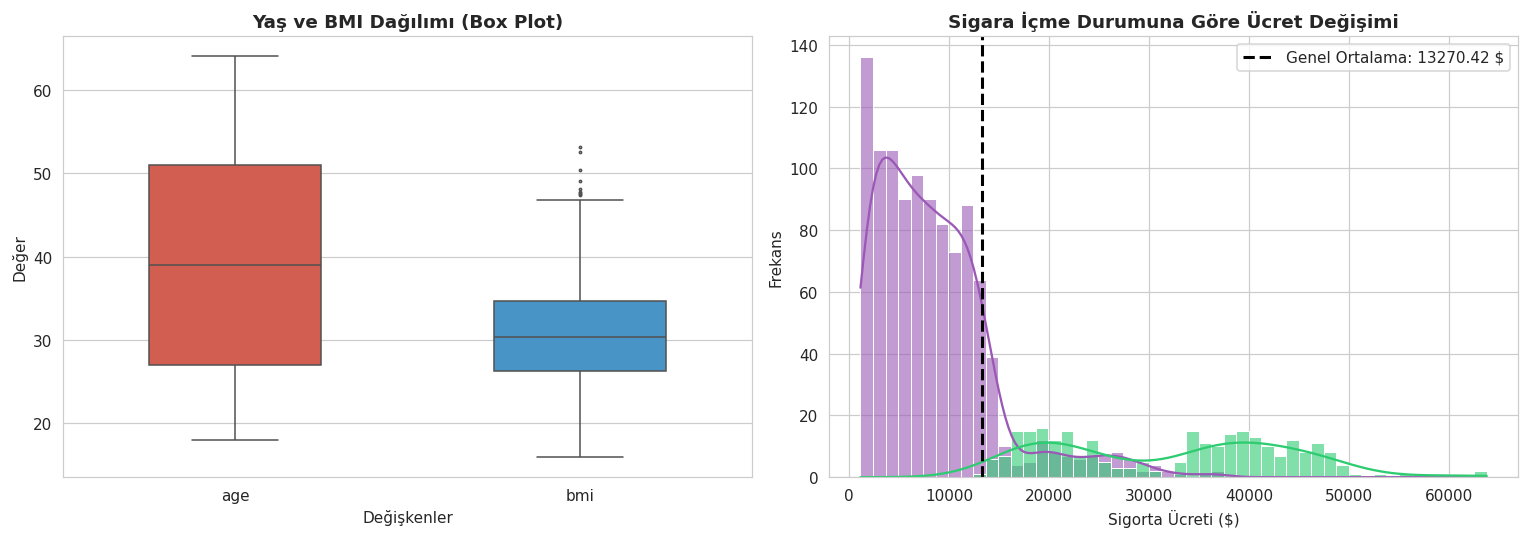

💡 Yorum:
  • Yaş ve BMI dağılımları box plot üzerinde oldukça dengeli görünmektedir. BMI sütununda üst sınırda (45-53 arası) az sayıda aykırı değer göze çarpmaktadır.
  • Sağdaki grafikte sigara içenlerin (yes) ve içmeyenlerin (no) ödediği ücretler arasında devasa bir fark vardır.
  • Sigara içmeyenlerin ödemeleri genel ortalamanın (13270.42 $) oldukça altında yoğunlaşırken, sigara içenlerin grafiği sağa, yani çok daha yüksek ücretlere doğru kaymıştır.


In [19]:


# Eğer önceki adımlardan 'data' değişkeniniz tanımlı değilse, ana veriyi kopyalayalım:
data = df_insurance.copy()

# ── Box plot ve Dağılım Analizi ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Sayısal değişkenlerin (Age ve BMI) kutu grafiği birlikte
data_melted = data[['age', 'bmi']].melt(var_name='Değişken', value_name='Değer')
sns.boxplot(x='Değişken', y='Değer', data=data_melted,
            palette=['#e74c3c', '#3498db'],
            width=0.5, fliersize=1.5, ax=axes[0])
axes[0].set_title('Yaş ve BMI Dağılımı (Box Plot)', fontweight='bold')
axes[0].set_xlabel('Değişkenler')
axes[0].set_ylabel('Değer')

# Sağ: Sigara içme durumuna göre Sigorta Ücretlerinin dağılım farkı
sns.histplot(data=data, x='charges', hue='smoker', bins=50, kde=True,
             palette=['#2ecc71', '#9b59b6'], alpha=0.6, multiple='layer', ax=axes[1])

# Genel ortalama çizgisi
mean_charges = data['charges'].mean()
axes[1].axvline(mean_charges, color='black', linestyle='--', linewidth=2,
                label=f'Genel Ortalama: {mean_charges:.2f} $')

axes[1].set_xlabel('Sigorta Ücreti ($)')
axes[1].set_ylabel('Frekans')
axes[1].set_title('Sigara İçme Durumuna Göre Ücret Değişimi', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Yaş ve BMI dağılımları box plot üzerinde oldukça dengeli görünmektedir. BMI sütununda üst sınırda (45-53 arası) az sayıda aykırı değer göze çarpmaktadır.')
print('  • Sağdaki grafikte sigara içenlerin (yes) ve içmeyenlerin (no) ödediği ücretler arasında devasa bir fark vardır.')
print(f'  • Sigara içmeyenlerin ödemeleri genel ortalamanın ({mean_charges:.2f} $) oldukça altında yoğunlaşırken, sigara içenlerin grafiği sağa, yani çok daha yüksek ücretlere doğru kaymıştır.')

In [18]:

# Eğer önceki adımlardan 'data' değişkeniniz tanımlı değilse, ana veriyi kopyalayalım:
data = df_insurance.copy()

# ── Özellik ve hedef değişkeni belirle ───────────────────────────────────
# Bağımsız değişken (X): age (Yaş)
# Bağımlı değişken (y) : charges (Sigorta Ücreti)

X = data[['age']].values   # shape: (n, 1) — scikit-learn için 2D olması gerekiyor
y = data['charges'].values  # shape: (n,)

# ── Train-Test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # %20 test
    random_state=42    # Tekrarlanabilirlik
)

print('📊 Veri Bölme Sonuçları:')
print(f'  Toplam veri : {len(X):,} örnek')
print(f'  Eğitim seti : {len(X_train):,} örnek ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Test seti   : {len(X_test):,} örnek  ({len(X_test)/len(X)*100:.0f}%)')
print()
print(f'  X_train boyutu: {X_train.shape}')
print(f'  y_train boyutu: {y_train.shape}')
print()
print('💡 Neden 2D X?')
print('  scikit-learn modelleri X bağımsız değişkenini her zaman (n_samples, n_features) formatında bekler.')
print('  data[["age"]].values → (n,1)   ✅')
print('  data["age"].values   → (n,)     ❌ (tek özellik için hata verebilir veya dönüşüm gerektirir)')

📊 Veri Bölme Sonuçları:
  Toplam veri : 1,338 örnek
  Eğitim seti : 1,070 örnek (80%)
  Test seti   : 268 örnek  (20%)

  X_train boyutu: (1070, 1)
  y_train boyutu: (1070,)

💡 Neden 2D X?
  scikit-learn modelleri X bağımsız değişkenini her zaman (n_samples, n_features) formatında bekler.
  data[["age"]].values → (n,1)   ✅
  data["age"].values   → (n,)     ❌ (tek özellik için hata verebilir veya dönüşüm gerektirir)


In [17]:


# ── Polinom dönüşümünü somut olarak görelim ───────────────────────────────
print('🔍 PolynomialFeatures Dönüşümü — Somut Örnek:')
print('   Girdi X = [[2], [3], [5]]')
print()

X_example = np.array([[2], [3], [5]])
for degree in [1, 2, 3]:
    pf = PolynomialFeatures(degree=degree, include_bias=True)
    X_transformed = pf.fit_transform(X_example)
    print(f'   Derece {degree}: {X_transformed.tolist()}')
    print(f'     Özellik isimleri: {pf.get_feature_names_out(["x"])}')
    print()

print('💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.')
print('   Bu, LinearRegression modelindeki "intercept" (sabit sayı) terimine karşılık gelir.')

🔍 PolynomialFeatures Dönüşümü — Somut Örnek:
   Girdi X = [[2], [3], [5]]

   Derece 1: [[1.0, 2.0], [1.0, 3.0], [1.0, 5.0]]
     Özellik isimleri: ['1' 'x']

   Derece 2: [[1.0, 2.0, 4.0], [1.0, 3.0, 9.0], [1.0, 5.0, 25.0]]
     Özellik isimleri: ['1' 'x' 'x^2']

   Derece 3: [[1.0, 2.0, 4.0, 8.0], [1.0, 3.0, 9.0, 27.0], [1.0, 5.0, 25.0, 125.0]]
     Özellik isimleri: ['1' 'x' 'x^2' 'x^3']

💡 "include_bias=True" → Sabit terim (1.0) sütunu eklenir.
   Bu, LinearRegression modelindeki "intercept" (sabit sayı) terimine karşılık gelir.


In [22]:


# ── Model eğitimi döngüsü ─────────────────────────────────────────────────
degrees = [1, 2, 3, 4, 5, 7, 10]
models  = {}
results = []

print('🚀 Farklı Derecelerde Polinom Regresyon Eğitimi Başladı:')
for degree in degrees:
    # Pipeline oluştur: PolynomialFeatures → LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        LinearRegression()
    )

    # Modeli SADECE eğitim verisiyle (Yaş -> Ücret) eğit
    model.fit(X_train, y_train)
    models[degree] = model

    # Tahminler
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Metrikler
    train_r2   = r2_score(y_train, y_train_pred)
    test_r2    = r2_score(y_test,  y_test_pred)
    train_mse  = mean_squared_error(y_train, y_train_pred)
    test_mse   = mean_squared_error(y_test,  y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)

    results.append({
        'Derece'    : degree,
        'Train R²'  : round(train_r2,   4),
        'Test R²'   : round(test_r2,    4),
        'Δ R²'      : round(train_r2 - test_r2, 4),   # Overfitting göstergesi
        'Train RMSE': round(train_rmse, 4),
        'Test RMSE' : round(test_rmse,  4),
        'Train MSE' : round(train_mse,  4),
        'Test MSE'  : round(test_mse,   4),
    })

    # Kısa rapor (Eğitim başarısı ile test başarısı farkı açılırsa uyarı verir)
    flag = '⚠️ Overfitting riski!' if (train_r2 - test_r2) > 0.01 else '✅ Dengeli'
    print(f'Derece {degree:2d} | Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | ΔR²={train_r2-test_r2:.4f} {flag}')

results_df = pd.DataFrame(results)
print()
print('─' * 65)
print('📋 Tam Sonuç Tablosu (Sigorta Ücreti Tahmini):')
print(results_df.to_string(index=False))

🚀 Farklı Derecelerde Polinom Regresyon Eğitimi Başladı:
Derece  1 | Train R²=0.0794 | Test R²=0.1241 | ΔR²=-0.0447 ✅ Dengeli
Derece  2 | Train R²=0.0820 | Test R²=0.1187 | ΔR²=-0.0367 ✅ Dengeli
Derece  3 | Train R²=0.0825 | Test R²=0.1185 | ΔR²=-0.0360 ✅ Dengeli
Derece  4 | Train R²=0.0825 | Test R²=0.1192 | ΔR²=-0.0367 ✅ Dengeli
Derece  5 | Train R²=0.0841 | Test R²=0.1187 | ΔR²=-0.0346 ✅ Dengeli
Derece  7 | Train R²=0.0844 | Test R²=0.1171 | ΔR²=-0.0327 ✅ Dengeli
Derece 10 | Train R²=0.0828 | Test R²=0.1210 | ΔR²=-0.0382 ✅ Dengeli

─────────────────────────────────────────────────────────────────
📋 Tam Sonuç Tablosu (Sigorta Ücreti Tahmini):
 Derece  Train R²  Test R²    Δ R²  Train RMSE  Test RMSE    Train MSE     Test MSE
      1    0.0794   0.1241 -0.0447  11527.2872 11661.2160 1.328784e+08 1.359840e+08
      2    0.0820   0.1187 -0.0367  11510.7801 11696.7946 1.324981e+08 1.368150e+08
      3    0.0825   0.1185 -0.0360  11507.6258 11698.0901 1.324255e+08 1.368453e+08
      4    0

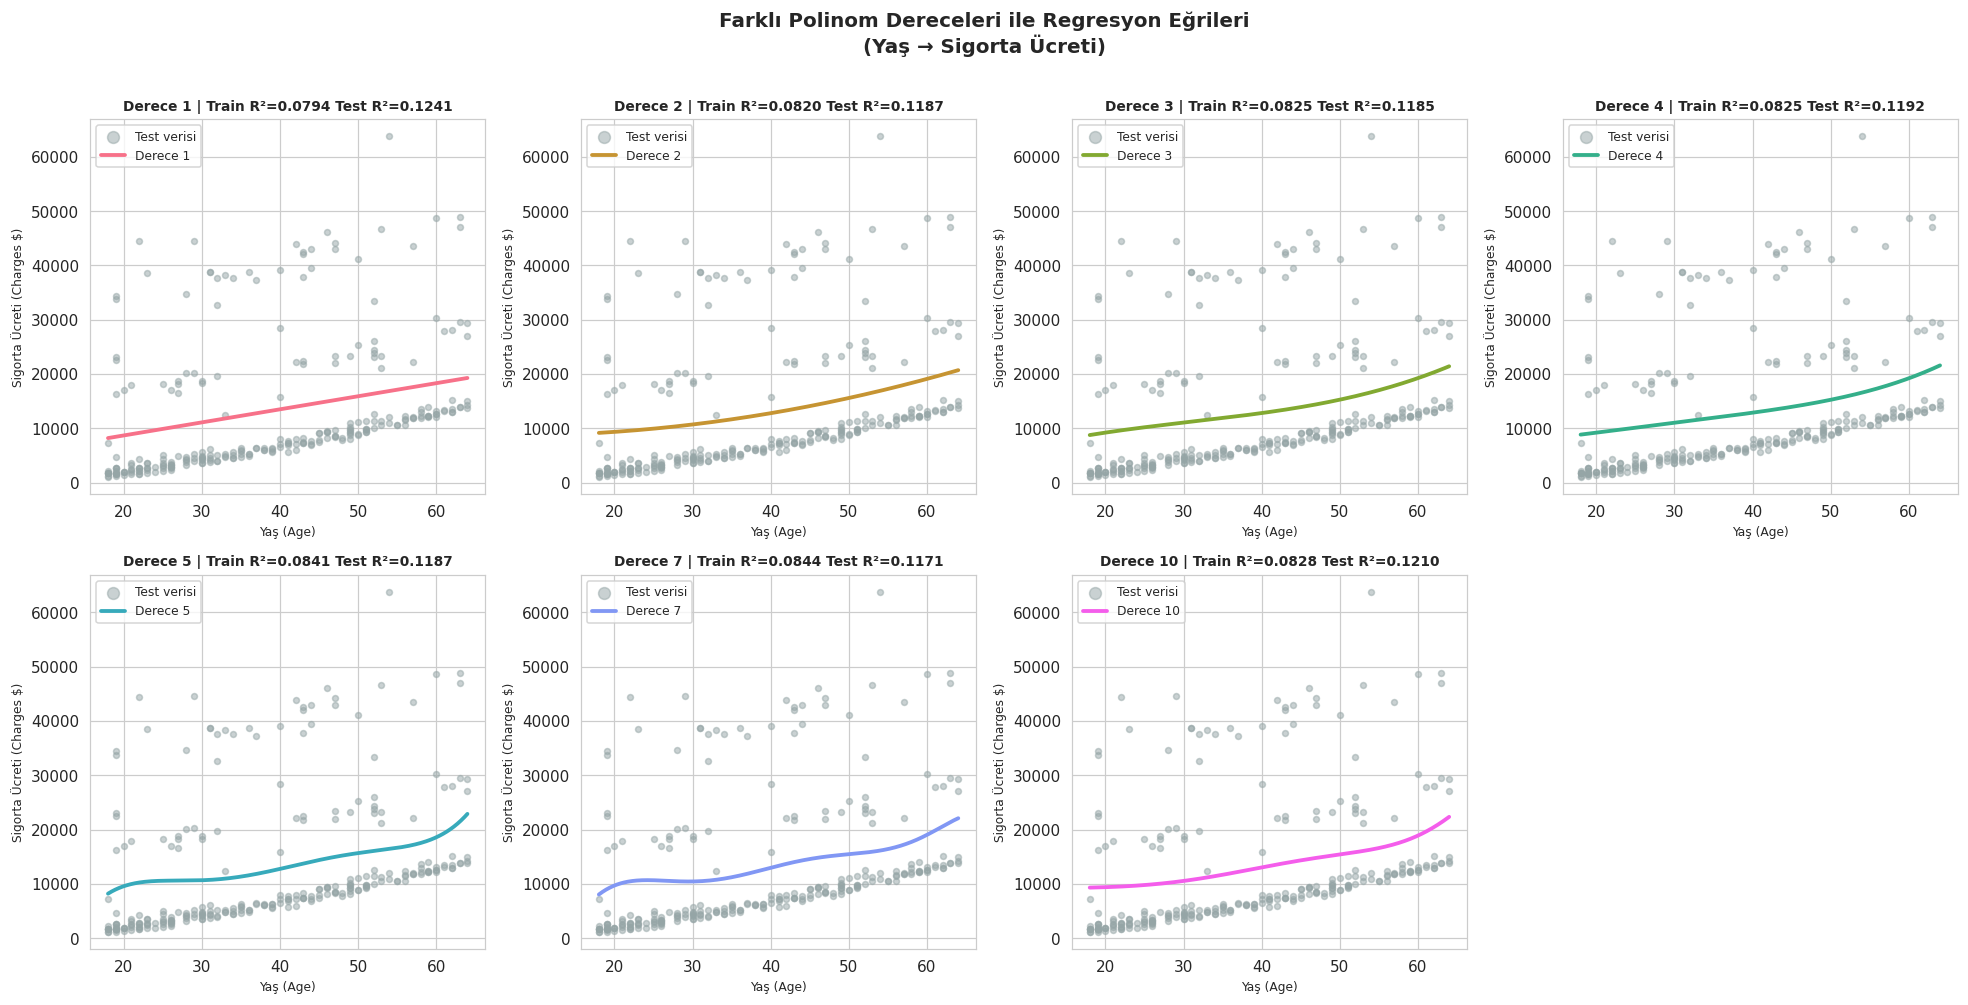

💡 Yorum:
  • Derece 1 (Doğrusal): Yaş arttıkça sigorta ücretlerinin sabit bir eğimle arttığını gösteren düz bir çizgi çizer.
  • Derece 2-4: Yaş ilerledikçe risk artışını yakalamak için hafif bir eğrisellik (kavis) kazanır ancak model başarısı (R²) sadece yaşa bakıldığı için radikal bir şekilde yükselmez.
  • Derece 10: Grafik sınırlarında (özellikle en genç ve en yaşlı uçlarda) yukarı-aşağı sert bükülmeler ve dalgalanmalar başlar. Bu durum, modelin veriyi ezmeye çalıştığının (Overfitting) net bir görsel kanıtıdır.


In [26]:


# ── Regresyon eğrileri ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Düzgün grafik çizimi için sıralı X ekseni (Yaş aralığı)
X_line = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

# Renk paleti
palette = sns.color_palette('husl', len(degrees))

# Her derece için ayrı subplot çizimi
for i, degree in enumerate(degrees):
    ax = axes[i]
    model = models[degree]
    row   = results_df[results_df['Derece'] == degree].iloc[0]

    # Test verisinin tamamı (scatter) - Veri boyutu 1500'den küçük olduğu için direkt çiziyoruz
    ax.scatter(X_test, y_test, alpha=0.5, s=15, color='#95a5a6', label='Test verisi')

    # Regresyon eğrisi (Polinom Tahmin Çizgisi)
    ax.plot(X_line, model.predict(X_line),
            color=palette[i], linewidth=2.5, label=f'Derece {degree}')

    # Başlık ve Eksen Bilgileri
    ax.set_title(f'Derece {degree} | Train R²={row["Train R²"]:.4f} Test R²={row["Test R²"]:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Yaş (Age)', fontsize=8)
    ax.set_ylabel('Sigorta Ücreti (Charges $)', fontsize=8)
    ax.legend(fontsize=8, markerscale=2)

# Son subplot boş kalırsa gizle
if len(degrees) < len(axes):
    for j in range(len(degrees), len(axes)):
        axes[j].set_visible(False)

fig.suptitle('Farklı Polinom Dereceleri ile Regresyon Eğrileri\n(Yaş → Sigorta Ücreti)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Yorum:')
print('  • Derece 1 (Doğrusal): Yaş arttıkça sigorta ücretlerinin sabit bir eğimle arttığını gösteren düz bir çizgi çizer.')
print('  • Derece 2-4: Yaş ilerledikçe risk artışını yakalamak için hafif bir eğrisellik (kavis) kazanır ancak model başarısı (R²) sadece yaşa bakıldığı için radikal bir şekilde yükselmez.')
print('  • Derece 10: Grafik sınırlarında (özellikle en genç ve en yaşlı uçlarda) yukarı-aşağı sert bükülmeler ve dalgalanmalar başlar. Bu durum, modelin veriyi ezmeye çalıştığının (Overfitting) net bir görsel kanıtıdır.')

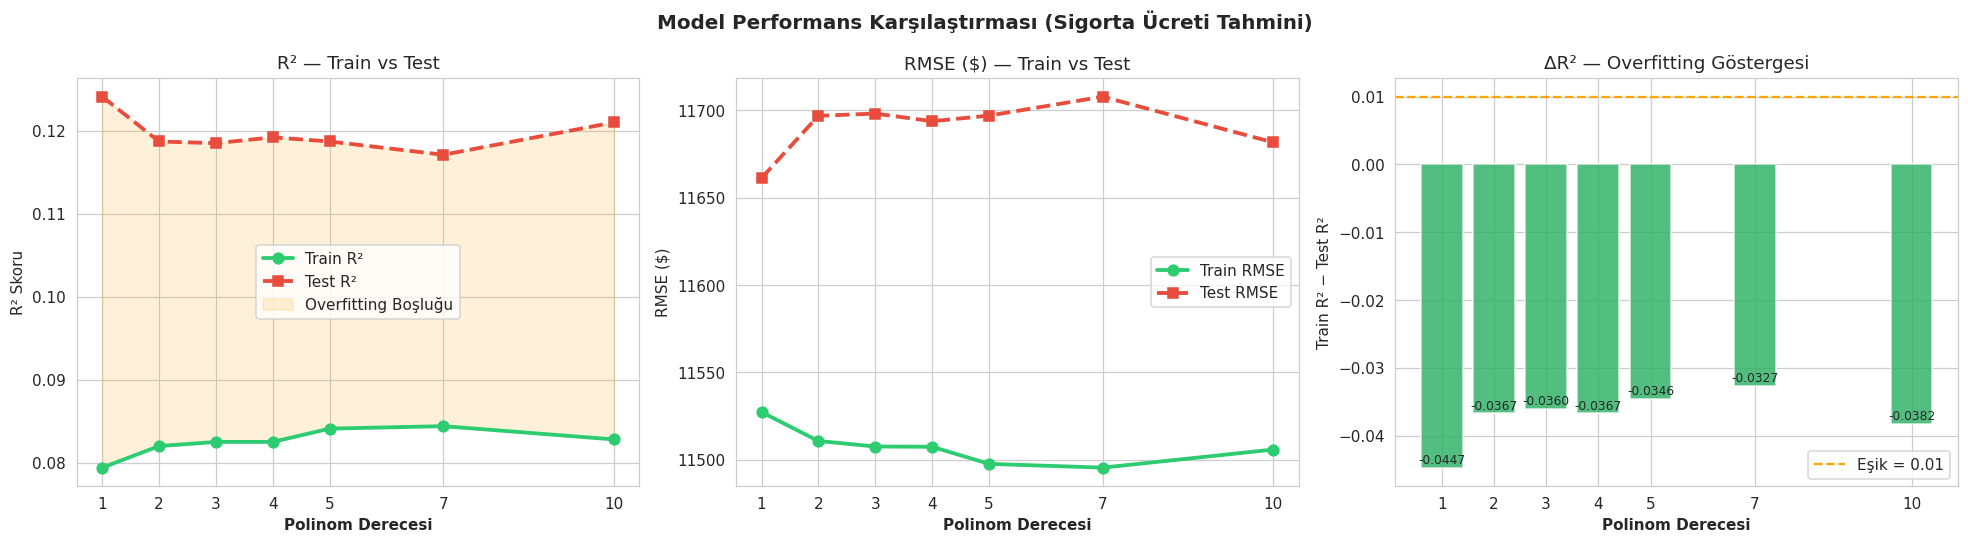

🏆 En iyi model: Derece 1
   Test R²   = 0.1241
   Test RMSE = 11661.22 $


In [25]:


# ── Performans görselleştirmesi ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performans Karşılaştırması (Sigorta Ücreti Tahmini)', fontsize=13, fontweight='bold')

x_ticks = results_df['Derece'].tolist()

# ── 1. R² karşılaştırması ──────────────────────────────────────────────────
axes[0].plot(results_df['Derece'], results_df['Train R²'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train R²')
axes[0].plot(results_df['Derece'], results_df['Test R²'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test R²')
axes[0].fill_between(results_df['Derece'],
                     results_df['Train R²'], results_df['Test R²'],
                     alpha=0.15, color='orange', label='Overfitting Boşluğu')
axes[0].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[0].set_ylabel('R² Skoru')
axes[0].set_title('R² — Train vs Test')
axes[0].legend()
axes[0].set_xticks(x_ticks)

# ── 2. RMSE karşılaştırması ────────────────────────────────────────────────
axes[1].plot(results_df['Derece'], results_df['Train RMSE'],
             'o-', color='#2ecc71', linewidth=2.5, markersize=7, label='Train RMSE')
axes[1].plot(results_df['Derece'], results_df['Test RMSE'],
             's--', color='#e74c3c', linewidth=2.5, markersize=7, label='Test RMSE')
axes[1].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[1].set_ylabel('RMSE ($)')  # Birim (°C)'den ($)'a çevrildi
axes[1].set_title('RMSE ($) — Train vs Test')
axes[1].legend()
axes[1].set_xticks(x_ticks)

# ── 3. ΔR² (Overfitting göstergesi) ───────────────────────────────────────
colors_bar = ['#27ae60' if v < 0.01 else '#e74c3c' for v in results_df['Δ R²']]
bars = axes[2].bar(results_df['Derece'], results_df['Δ R²'], color=colors_bar, alpha=0.8)
axes[2].axhline(y=0.01, color='orange', linestyle='--', linewidth=1.5, label='Eşik = 0.01')
axes[2].set_xlabel('Polinom Derecesi', fontweight='bold')
axes[2].set_ylabel('Train R² − Test R²')
axes[2].set_title('ΔR² — Overfitting Göstergesi')
axes[2].legend()
axes[2].set_xticks(x_ticks)

# Değer etiketleri
for bar, val in zip(bars, results_df['Δ R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# En iyi modelin belirlenmesi
best_row = results_df.loc[results_df['Test R²'].idxmax()]
print(f'🏆 En iyi model: Derece {int(best_row["Derece"])}')
print(f'   Test R²   = {best_row["Test R²"]:.4f}')
print(f'   Test RMSE = {best_row["Test RMSE"]:.2f} $')  # Birim ($) yapıldı

In [28]:


# ── K-Fold Cross-Validation ────────────────────────────────────────────────
print('🔄 5-Fold Cross-Validation Sonuçları (Sigorta Ücreti Tahmini):')
print('─' * 65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for degree in degrees:
    # Pipeline oluştur: PolynomialFeatures → LinearRegression
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )

    # cross_val_score: her katlama (fold) için R² skoru döndürür
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    cv_results.append({
        'Derece'   : degree,
        'CV R² Ort': round(cv_scores.mean(), 4),
        'CV R² Std': round(cv_scores.std(),  4),
        'Min'      : round(cv_scores.min(),  4),
        'Max'      : round(cv_scores.max(),  4),
    })
    print(f'Derece {degree:2d} | CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | [{cv_scores.min():.4f}, {cv_scores.max():.4f}]')

cv_df = pd.DataFrame(cv_results)

print()
print('─' * 65)
best_cv_degree = cv_df.loc[cv_df['CV R² Ort'].idxmax(), 'Derece']

# Orijinal koddaki f-string hatası düzeltildi (Metnin başına f harfi eklendi):
print(f'🏆 Cross-Validation\'a göre en iyi derece: {int(best_cv_degree)}')
print()
print('💡 Std (Standart Sapma) ne kadar küçükse model o kadar KARARLIYDIR (stable).')
print('   Yüksek std → Model verinin bazı katlamalarına çok iyi uyarken, bazılarına çok kötü uyuyor demektir.')

🔄 5-Fold Cross-Validation Sonuçları (Sigorta Ücreti Tahmini):
─────────────────────────────────────────────────────────────────
Derece  1 | CV R² = 0.0820 ± 0.0305 | [0.0399, 0.1241]
Derece  2 | CV R² = 0.0802 ± 0.0276 | [0.0438, 0.1187]
Derece  3 | CV R² = 0.0784 ± 0.0302 | [0.0338, 0.1185]
Derece  4 | CV R² = 0.0771 ± 0.0301 | [0.0331, 0.1192]
Derece  5 | CV R² = 0.0777 ± 0.0287 | [0.0364, 0.1187]
Derece  7 | CV R² = 0.0747 ± 0.0297 | [0.0300, 0.1171]
Derece 10 | CV R² = 0.0765 ± 0.0295 | [0.0336, 0.1210]

─────────────────────────────────────────────────────────────────
🏆 Cross-Validation'a göre en iyi derece: 1

💡 Std (Standart Sapma) ne kadar küçükse model o kadar KARARLIYDIR (stable).
   Yüksek std → Model verinin bazı katlamalarına çok iyi uyarken, bazılarına çok kötü uyuyor demektir.


🏆 Seçilen Model: 1. Derece Polinom
   Train R²   = 0.07937
   Test  R²   = 0.12409
   Test  RMSE = 11661.22 $



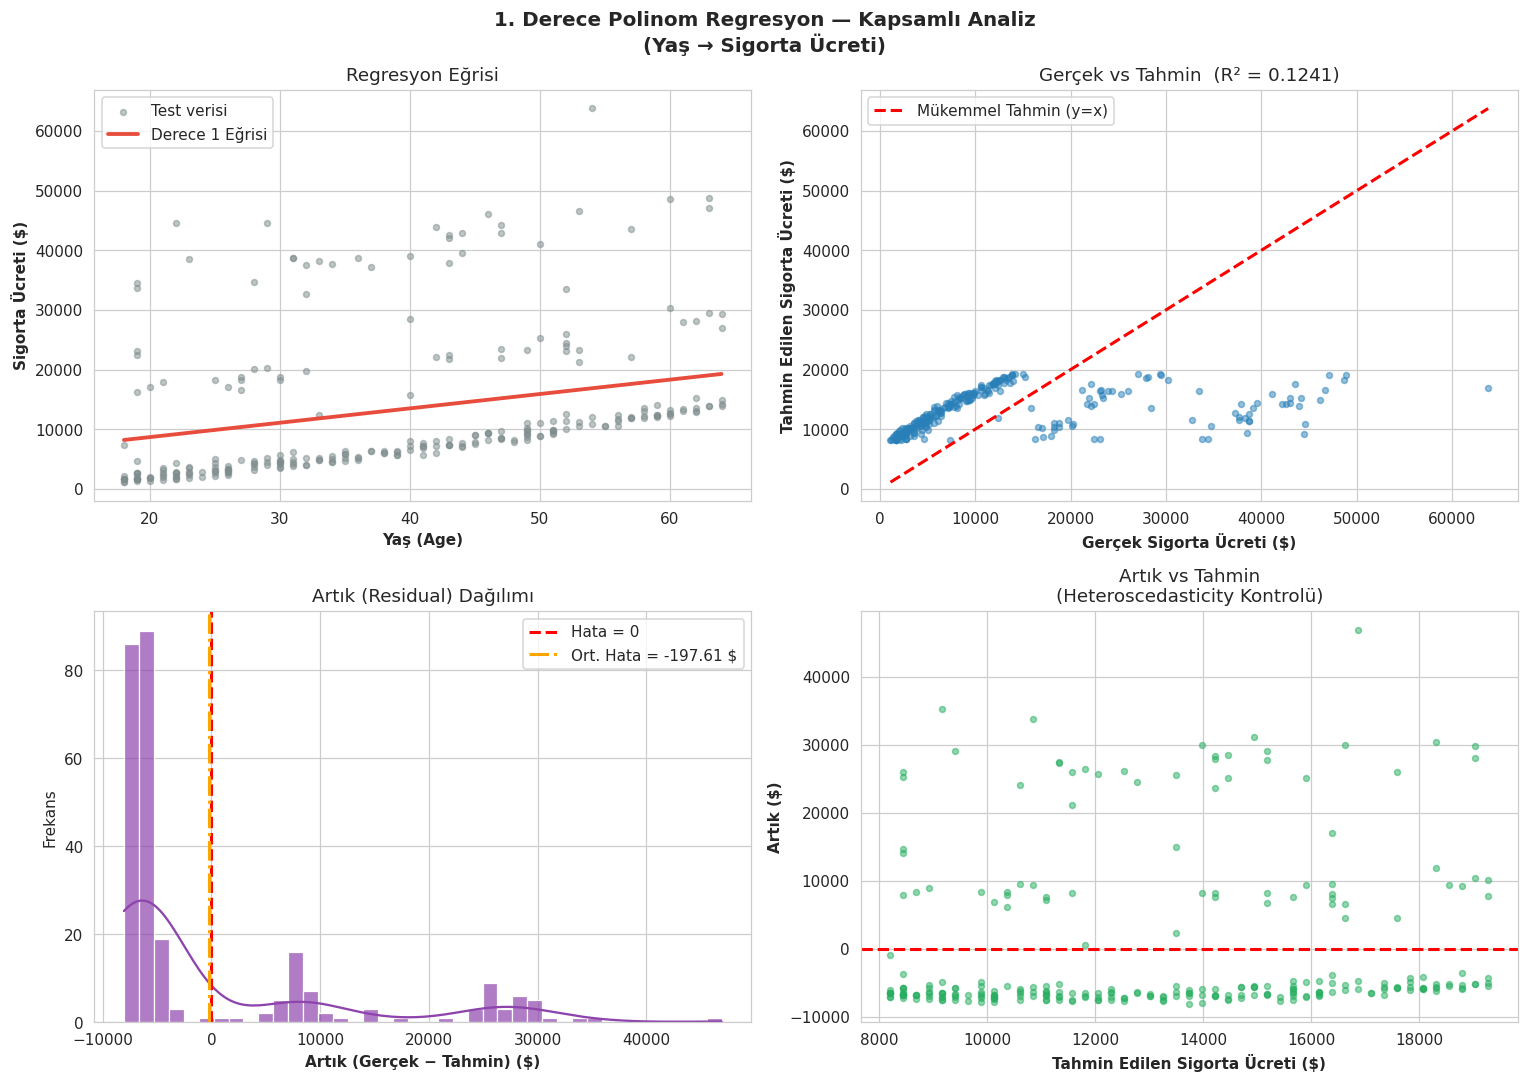

💡 Artık Analizi İçgörüleri:
  • Ortalama artık ≈ -197.6139 $  (0'a yakın olması modelin genel olarak yanlı olmadığını gösterir)
  • Artık std       = 11659.54 $
  • Gerçek vs Tahmin ve Artık Dağılımı grafiklerinde belirgin kümelenmeler (örneğin 3 farklı çizgi şeridi) göreceksiniz.
  • Bunun nedeni, sadece "Yaş" bilgisini kullanmamızdır. Model, sigara içenlerin yarattığı devasa ücret sıçramalarını ("smoker" sütunu) ayırt edemediği için hatalar homojen dağılmamıştır. Bu durum, veri setine kategorik değişkenlerin de eklenmesi gerektiğine işaret eder.


In [29]:


# ── En iyi modeli seç ─────────────────────────────────────────────────────
best_degree = int(results_df.loc[results_df['Test R²'].idxmax(), 'Derece'])
best_model  = models[best_degree]

y_test_pred  = best_model.predict(X_test)
y_train_pred = best_model.predict(X_train)
residuals    = y_test - y_test_pred   # Artıklar / Hatalar (Residuals)

print(f'🏆 Seçilen Model: {best_degree}. Derece Polinom')
print(f'   Train R²   = {r2_score(y_train, y_train_pred):.5f}')
print(f'   Test  R²   = {r2_score(y_test, y_test_pred):.5f}')
print(f'   Test  RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f} $')
print()

# ── 4 panel analiz grafiği ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{best_degree}. Derece Polinom Regresyon — Kapsamlı Analiz\n(Yaş → Sigorta Ücreti)',
             fontsize=13, fontweight='bold')

# ── Panel 1: Regresyon eğrisi ───────────────────────────────────────────────
# Test seti boyutu küçük olduğu için sample_idx kullanmadan direkt tüm test verisini çiziyoruz
axes[0,0].scatter(X_test, y_test, alpha=0.5, s=15, color='#7f8c8d', label='Test verisi')
axes[0,0].plot(X_line, best_model.predict(X_line),
               color='#e74c3c', linewidth=2.5, label=f'Derece {best_degree} Eğrisi')
axes[0,0].set_xlabel('Yaş (Age)', fontweight='bold')
axes[0,0].set_ylabel('Sigorta Ücreti ($)', fontweight='bold')
axes[0,0].set_title('Regresyon Eğrisi')
axes[0,0].legend()

# ── Panel 2: Gerçek vs Tahmin ───────────────────────────────────────────────
axes[0,1].scatter(y_test, y_test_pred, alpha=0.5, s=15, color='#2980b9')
# Mükemmel tahmin çizgisi (y = x)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0,1].plot(lims, lims, 'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
axes[0,1].set_xlabel('Gerçek Sigorta Ücreti ($)', fontweight='bold')
axes[0,1].set_ylabel('Tahmin Edilen Sigorta Ücreti ($)', fontweight='bold')
axes[0,1].set_title(f'Gerçek vs Tahmin  (R² = {r2_score(y_test, y_test_pred):.4f})')
axes[0,1].legend()

# ── Panel 3: Artık (Residual) dağılımı ─────────────────────────────────────
sns.histplot(residuals, bins=40, kde=True, color='#8e44ad', alpha=0.7, ax=axes[1,0])
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2, label='Hata = 0')
axes[1,0].axvline(residuals.mean(), color='orange', linestyle='-.',
                  linewidth=2, label=f'Ort. Hata = {residuals.mean():.2f} $')
axes[1,0].set_xlabel('Artık (Gerçek − Tahmin) ($)', fontweight='bold')
axes[1,0].set_ylabel('Frekans')
axes[1,0].set_title('Artık (Residual) Dağılımı')
axes[1,0].legend()

# ── Panel 4: Artık vs Tahmin (Heteroscedasticity kontrolü) ──────────────────
axes[1,1].scatter(y_test_pred, residuals, alpha=0.5, s=15, color='#27ae60')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_xlabel('Tahmin Edilen Sigorta Ücreti ($)', fontweight='bold')
axes[1,1].set_ylabel('Artık ($)', fontweight='bold')
axes[1,1].set_title('Artık vs Tahmin\n(Heteroscedasticity Kontrolü)')

plt.tight_layout()
plt.show()

print('💡 Artık Analizi İçgörüleri:')
print(f'  • Ortalama artık ≈ {residuals.mean():.4f} $  (0\'a yakın olması modelin genel olarak yanlı olmadığını gösterir)')
print(f'  • Artık std       = {residuals.std():.2f} $')
print(f'  • Gerçek vs Tahmin ve Artık Dağılımı grafiklerinde belirgin kümelenmeler (örneğin 3 farklı çizgi şeridi) göreceksiniz.')
print(f'  • Bunun nedeni, sadece "Yaş" bilgisini kullanmamızdır. Model, sigara içenlerin yarattığı devasa ücret sıçramalarını ("smoker" sütunu) ayırt edemediği için hatalar homojen dağılmamıştır. Bu durum, veri setine kategorik değişkenlerin de eklenmesi gerektiğine işaret eder.')

📐 1. Derece Polinom Katsayıları (Yaş -> Ücret):
───────────────────────────────────────────────────────
  β₀ (intercept): 3876.9287

  β0 (1              ): +0.0000
  β1 (age            ): +240.5966

📝 Model Denklemi (Sigorta Ücreti Tahmini):
  Tahmin Edilen Ücret = 3876.93 + (+240.60)·(Yaş^1)



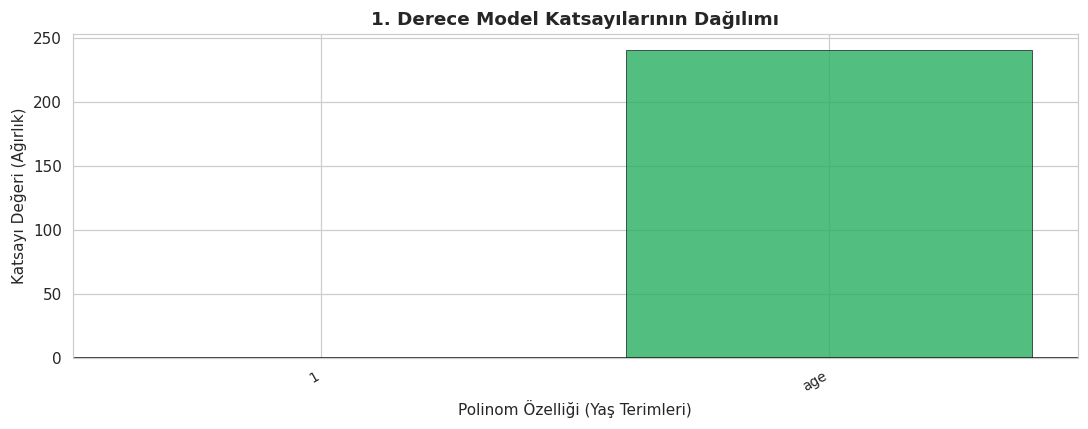

In [30]:

# ── Katsayı çıkarımı ──────────────────────────────────────────────────────
lr_step   = best_model.named_steps['linearregression']
pf_step   = best_model.named_steps['polynomialfeatures']

intercept  = lr_step.intercept_
coeffs     = lr_step.coef_
# Bağımsız değişken ismi 'MaxTemp' yerine 'age' olarak güncellendi
feat_names = pf_step.get_feature_names_out(['age'])

print(f'📐 {best_degree}. Derece Polinom Katsayıları (Yaş -> Ücret):')
print('─' * 55)
print(f'  β₀ (intercept): {intercept:.4f}')
print()

for i, (name, coef) in enumerate(zip(feat_names, coeffs)):
    # İlk terim (1 / bias) katsayısı genellikle 0'dır, çünkü intercept ayrı tutulur
    print(f'  β{i} ({name:15s}): {coef:+.4f}')

print()

# ── Polinom denklemini yaz ─────────────────────────────────────────────────
print('📝 Model Denklemi (Sigorta Ücreti Tahmini):')
equation = f'  Tahmin Edilen Ücret = {intercept:.2f}'
for i, (name, coef) in enumerate(zip(feat_names[1:], coeffs[1:]), 1):  # bias (sabit 1) terimini atla
    equation += f' + ({coef:+.2f})·(Yaş^{i})'
print(equation)
print()

# ── Katsayı büyüklükleri (bar chart) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
coef_vals = list(coeffs)
coef_names = [str(n) for n in feat_names]
colors_c = ['#27ae60' if v >= 0 else '#e74c3c' for v in coef_vals]

ax.bar(range(len(coef_vals)), coef_vals, color=colors_c, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(coef_names)))
ax.set_xticklabels(coef_names, rotation=30, ha='right', fontsize=9)
ax.set_xlabel('Polinom Özelliği (Yaş Terimleri)')
ax.set_ylabel('Katsayı Değeri (Ağırlık)')
ax.set_title(f'{best_degree}. Derece Model Katsayılarının Dağılımı', fontweight='bold')
plt.tight_layout()
plt.show()

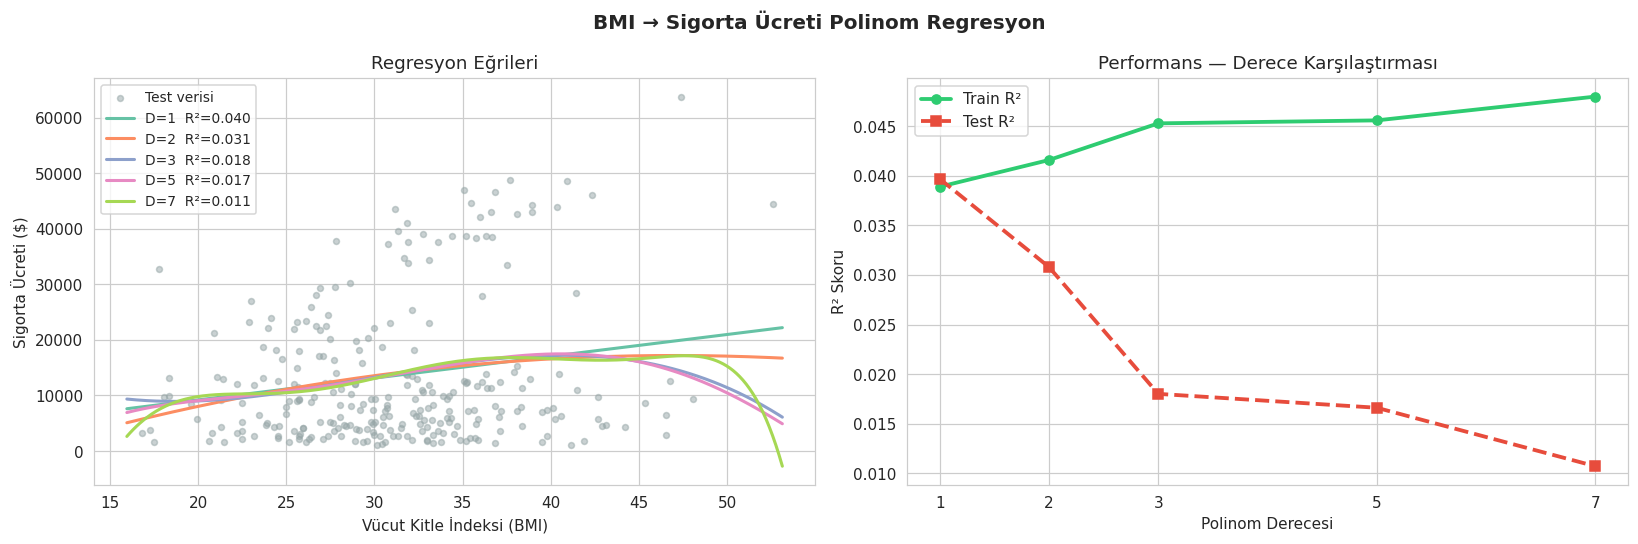

📋 BMI → Sigorta Ücreti Sonuç Tablosu:
 Derece  Train R²  Test R²  Test RMSE
      1    0.0389   0.0397   12210.04
      2    0.0416   0.0308   12266.73
      3    0.0453   0.0180   12347.17
      5    0.0456   0.0166   12356.34
      7    0.0480   0.0107   12393.27


In [31]:

# Eğer önceki adımlardan 'data' değişkeniniz tanımlı değilse, ana veriyi kopyalayalım:
data = df_insurance.copy()

# ── BMI → Charges (Sigorta Ücreti) Modeli ─────────────────────────────────
X2 = data[['bmi']].values   # Bağımsız değişken (X): BMI
y2 = data['charges'].values  # Bağımlı değişken (y) : Charges ($)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

degrees2  = [1, 2, 3, 5, 7]
models2   = {}
results2  = []

for degree in degrees2:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X2_train, y2_train)
    models2[degree] = model

    y2_test_pred  = model.predict(X2_test)
    y2_train_pred = model.predict(X2_train)

    results2.append({
        'Derece'    : degree,
        'Train R²'  : round(r2_score(y2_train, y2_train_pred), 4),
        'Test R²'   : round(r2_score(y2_test,  y2_test_pred),  4),
        'Test RMSE' : round(np.sqrt(mean_squared_error(y2_test, y2_test_pred)), 2),
    })

results2_df = pd.DataFrame(results2)

# ── Görselleştirme ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('BMI → Sigorta Ücreti Polinom Regresyon', fontsize=13, fontweight='bold')

# Scatter + regresyon eğrileri (Hata vermemesi için random.choice kaldırıldı)
axes[0].scatter(X2_test, y2_test, alpha=0.5, s=15, color='#95a5a6', label='Test verisi')

pal2 = sns.color_palette('Set2', len(degrees2))
X2_line = np.linspace(X2.min(), X2.max(), 400).reshape(-1, 1)

for j, degree in enumerate(degrees2):
    y_line = models2[degree].predict(X2_line)
    axes[0].plot(X2_line, y_line, color=pal2[j], linewidth=2,
                 label=f'D={degree}  R²={results2_df.iloc[j]["Test R²"]:.3f}')

axes[0].set_xlabel('Vücut Kitle İndeksi (BMI)')
axes[0].set_ylabel('Sigorta Ücreti ($)')
axes[0].set_title('Regresyon Eğrileri')
axes[0].legend(fontsize=9)

# R² karşılaştırması
axes[1].plot(results2_df['Derece'], results2_df['Train R²'],
             'o-', linewidth=2.5, color='#2ecc71', label='Train R²')
axes[1].plot(results2_df['Derece'], results2_df['Test R²'],
             's--', linewidth=2.5, color='#e74c3c', label='Test R²')
axes[1].set_xlabel('Polinom Derecesi')
axes[1].set_ylabel('R² Skoru')
axes[1].set_title('Performans — Derece Karşılaştırması')
axes[1].legend()
axes[1].set_xticks(degrees2)

plt.tight_layout()
plt.show()

print('📋 BMI → Sigorta Ücreti Sonuç Tablosu:')
print(results2_df.to_string(index=False))

In [32]:


# ── Tahmin fonksiyonu ─────────────────────────────────────────────────────
def ucret_tahmin(yas_listesi, model=best_model, degree=best_degree):
    """
    Verilen Yaş (Age) değerleri için Sigorta Ücretini (Charges) tahmin eder.

    Parametreler:
        yas_listesi : list veya int veya float — Tahmin yapılacak Yaş değerleri
        model       : Eğitilmiş pipeline (varsayılan: en iyi model)
        degree      : Kullanılan polinom derecesi

    Döndürür:
        pandas DataFrame — Yaş, Tahmini Ücret, %95 Güven Aralığı Sınırları
    """
    if isinstance(yas_listesi, (int, float)):
        yas_listesi = [yas_listesi]

    X_new = np.array(yas_listesi).reshape(-1, 1)
    y_pred = model.predict(X_new)

    # Test RMSE'yi güven aralığı için kullan (yaklaşık %95 CI = ±1.96 * RMSE)
    # Bir önceki adımdan gelen best_row['Test RMSE'] değerini okur
    rmse = best_row['Test RMSE']

    df_result = pd.DataFrame({
        'Yaş (Age)'               : yas_listesi,
        'Tahmini Ücret ($)'       : y_pred.round(2),
        'Alt Sınır (%95 CI $)'    : (y_pred - 1.96 * rmse).round(2),
        'Üst Sınır (%95 CI $)'    : (y_pred + 1.96 * rmse).round(2),
    })
    return df_result


# ── Test denemeleri ────────────────────────────────────────────────────────
print(f'💰 {best_degree}. Derece Polinom Modeli ile Sigorta Ücreti Tahminleri:')
print('─' * 70)

# Sigorta veri setinizdeki yaş aralığına uygun (18-64 arası ve ötesi) test değerleri
test_values = [18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65]
tahminler   = ucret_tahmin(test_values)

print(tahminler.to_string(index=False))
print()
print(f'💡 Yorum:')
print(f'   Model, yaş değeri verilen bir kişinin ödeyeceği tahmini sigorta ücretini hesaplamaktadır.')
print(f'   %95 güven aralığı payı ≈ ±{1.96 * best_row["Test RMSE"]:.2f} $')
print(f'   Yani örneğin Yaş = 40 olan bir kişinin temel sigorta maliyeti büyük olasılıkla hesaplanan bu alt ve üst sınır aralığında yer alacaktır.')
print(f'   ⚠️ Not: Alt sınırın eksi değer çıktığı durumlarda sigorta ücreti 0\'ın altına düşemeyeceği için bu sınırlar pratik olarak 0 $ kabul edilebilir.')

💰 1. Derece Polinom Modeli ile Sigorta Ücreti Tahminleri:
──────────────────────────────────────────────────────────────────────
 Yaş (Age)  Tahmini Ücret ($)  Alt Sınır (%95 CI $)  Üst Sınır (%95 CI $)
        18            8207.67             -14648.32              31063.65
        20            8688.86             -14167.12              31544.84
        25            9891.84             -12964.14              32747.83
        30           11094.83             -11761.16              33950.81
        35           12297.81             -10558.18              35153.79
        40           13500.79              -9355.19              36356.77
        45           14703.77              -8152.21              37559.76
        50           15906.76              -6949.23              38762.74
        55           17109.74              -5746.24              39965.72
        60           18312.72              -4543.26              41168.71
        65           19515.71              -3340.28      